In [17]:
# ============================================================
# Import all libraries we need
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor   # our main ML model
from sklearn.linear_model import LinearRegression    # simpler model to compare
from sklearn.model_selection import train_test_split # splits data into train/test
from sklearn.metrics import mean_absolute_error, r2_score  # accuracy metrics
from sklearn.preprocessing import LabelEncoder       # converts text to numbers

import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"   pandas version: {pd.__version__}")
print(f"   scikit-learn version: {__import__('sklearn').__version__}")

✅ All libraries imported successfully!
   pandas version: 2.2.2
   scikit-learn version: 1.6.1


In [18]:
# ============================================================
# Load the CSV dataset into Python
# ============================================================

df = pd.read_csv('House_Rent_Dataset.csv')

print("✅ Dataset loaded!")
print(f"   Rows (apartments): {df.shape[0]}")
print(f"   Columns (features): {df.shape[1]}")

✅ Dataset loaded!
   Rows (apartments): 4746
   Columns (features): 12


In [19]:
# ============================================================
# Look at what's inside the dataset
# ============================================================

print("=" * 60)
print("COLUMN NAMES")
print("=" * 60)
print(df.columns.tolist())

print("\n" + "=" * 60)
print("FIRST 5 ROWS (preview)")
print("=" * 60)
df.head()

COLUMN NAMES
['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']

FIRST 5 ROWS (preview)


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [20]:
# ============================================================
# Exploratory Data Analysis (EDA)
# ============================================================

print("=" * 60)
print("1. DATA TYPES (what kind of data is in each column?)")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("2. MISSING VALUES (are there any empty cells?)")
print("=" * 60)
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

print("\n" + "=" * 60)
print("3. STATISTICAL SUMMARY (min, max, average, etc.)")
print("=" * 60)
print(df.describe())

print("\n" + "=" * 60)
print("4. UNIQUE VALUES IN KEY COLUMNS")
print("=" * 60)
print("Cities:", df['City'].unique())
print("Furnishing:", df['Furnishing Status'].unique())
print("Tenant types:", df['Tenant Preferred'].unique())

print("\n" + "=" * 60)
print("5. RENT RANGE")
print("=" * 60)
print(f"Minimum Rent : ₹{df['Rent'].min():,}")
print(f"Maximum Rent : ₹{df['Rent'].max():,}")
print(f"Average Rent : ₹{df['Rent'].mean():,.0f}")
print(f"Median Rent  : ₹{df['Rent'].median():,.0f}")

print("\n" + "=" * 60)
print("6. HOW MANY APARTMENTS PER CITY?")
print("=" * 60)
print(df['City'].value_counts())

1. DATA TYPES (what kind of data is in each column?)
Posted On            object
BHK                   int64
Rent                  int64
Size                  int64
Floor                object
Area Type            object
Area Locality        object
City                 object
Furnishing Status    object
Tenant Preferred     object
Bathroom              int64
Point of Contact     object
dtype: object

2. MISSING VALUES (are there any empty cells?)
Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

Total missing values: 0

3. STATISTICAL SUMMARY (min, max, average, etc.)
               BHK          Rent         Size     Bathroom
count  4746.000000  4.746000e+03  4746.000000  4746.000000
mean      2.083860  3.499345e+04   967.490729     1.965866
std     

In [21]:
# ============================================================
# Clean the data
# ============================================================

print(f"Shape before cleaning: {df.shape}")

columns_to_remove = ['Area Locality', 'Point of Contact', 'Floor', 'Area Type']
df.drop(columns=columns_to_remove, inplace=True, errors='ignore')
print(f"Columns after removal: {df.columns.tolist()}")

dups = df.duplicated().sum()
print(f"\nDuplicate rows found: {dups}")
df.drop_duplicates(inplace=True)

upper_limit = df['Rent'].quantile(0.99)
lower_limit = df['Rent'].quantile(0.01)
print(f"\nRemoving rents above ₹{upper_limit:,.0f} (top 1% — luxury outliers)")
print(f"Removing rents below ₹{lower_limit:,.0f} (bottom 1% — data errors)")

df = df[(df['Rent'] >= lower_limit) & (df['Rent'] <= upper_limit)]

print(f"\nShape after cleaning: {df.shape}")
print(f"Rent range now: ₹{df['Rent'].min():,} — ₹{df['Rent'].max():,}")
print(f"Average rent: ₹{df['Rent'].mean():,.0f}")

# ---- Save cleaned data ----
df.to_csv('cleaned_rent_data.csv', index=False)
print("\n✅ Cleaned data saved as 'cleaned_rent_data.csv'")
print("   (You can see it in the Files panel on the left)")

Shape before cleaning: (4746, 12)
Columns after removal: ['Posted On', 'BHK', 'Rent', 'Size', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom']

Duplicate rows found: 35

Removing rents above ₹300,000 (top 1% — luxury outliers)
Removing rents below ₹4,000 (bottom 1% — data errors)

Shape after cleaning: (4636, 8)
Rent range now: ₹4,000 — ₹300,000
Average rent: ₹30,867

✅ Cleaned data saved as 'cleaned_rent_data.csv'
   (You can see it in the Files panel on the left)


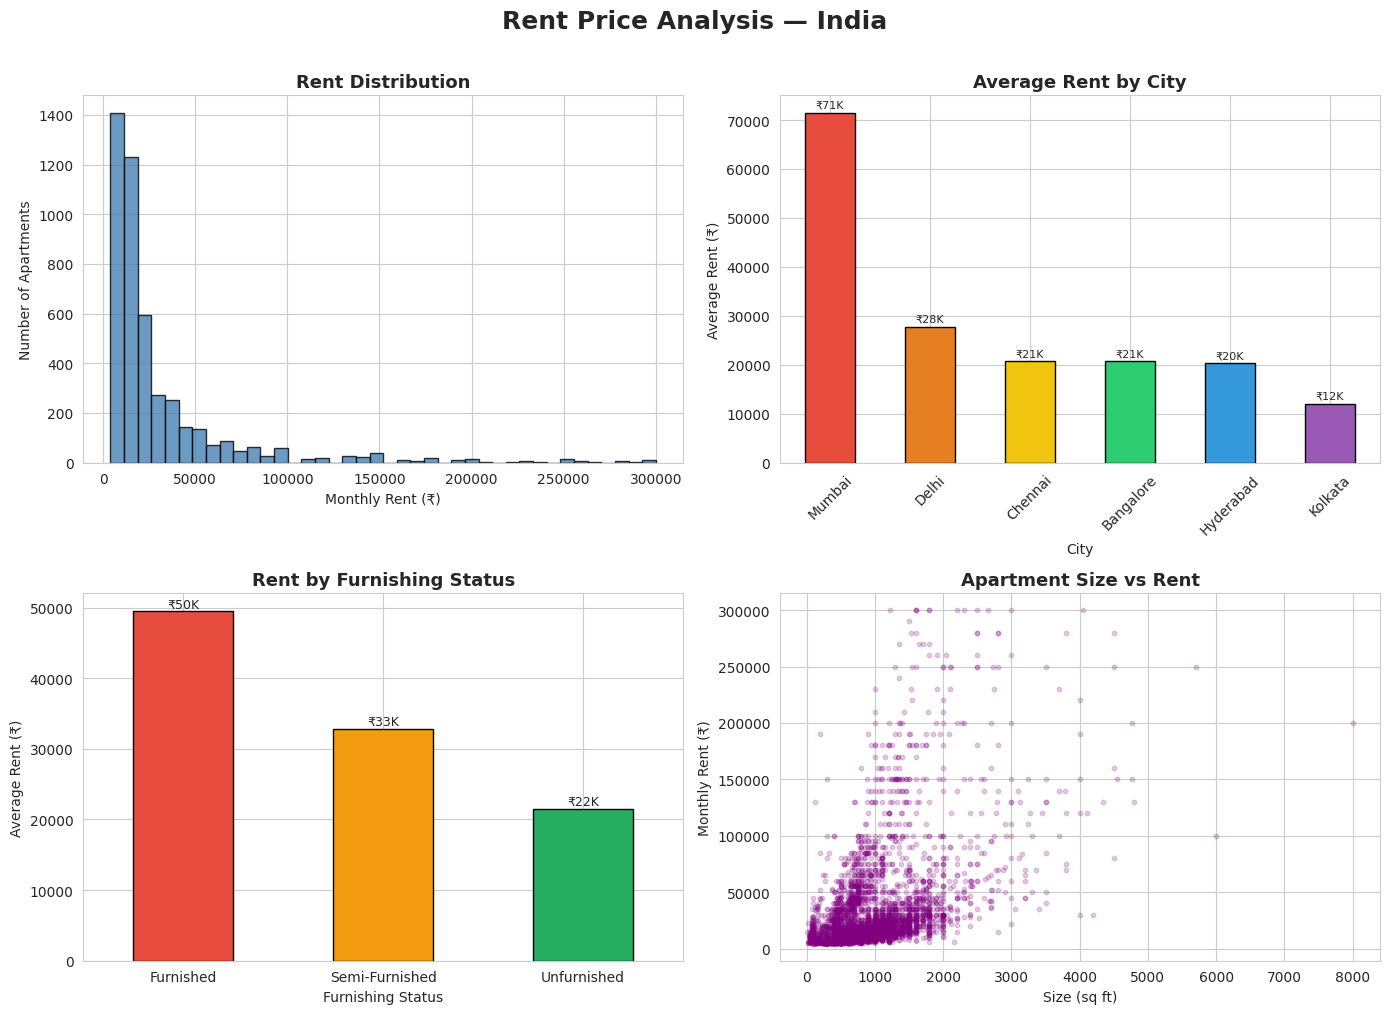

✅ Chart 1 complete!


In [22]:
# ============================================================
# Visualize rent patterns with charts
# ============================================================

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Rent Price Analysis — India', fontsize=18, fontweight='bold', y=1.01)

# ---- CHART 1: How is rent spread out? ----
df['Rent'].hist(bins=40, ax=axes[0,0], color='steelblue', edgecolor='black', alpha=0.8)
axes[0,0].set_title('Rent Distribution', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Monthly Rent (₹)')
axes[0,0].set_ylabel('Number of Apartments')

# ---- CHART 2: Which city has highest average rent? ----
avg_by_city = df.groupby('City')['Rent'].mean().sort_values(ascending=False)
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6','#1abc9c','#34495e']
avg_by_city.plot(kind='bar', ax=axes[0,1], color=colors, edgecolor='black')
axes[0,1].set_title('Average Rent by City', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('City')
axes[0,1].set_ylabel('Average Rent (₹)')
axes[0,1].tick_params(axis='x', rotation=45)
for i, v in enumerate(avg_by_city):
    axes[0,1].text(i, v + 1000, f'₹{v/1000:.0f}K', ha='center', fontsize=8)

# ---- CHART 3: Does furnishing affect rent? ----
avg_by_furn = df.groupby('Furnishing Status')['Rent'].mean().sort_values(ascending=False)
avg_by_furn.plot(kind='bar', ax=axes[1,0],
                  color=['#e74c3c','#f39c12','#27ae60'], edgecolor='black')
axes[1,0].set_title('Rent by Furnishing Status', fontsize=13, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].set_ylabel('Average Rent (₹)')
for i, v in enumerate(avg_by_furn):
    axes[1,0].text(i, v + 500, f'₹{v/1000:.0f}K', ha='center', fontsize=9)

# ---- CHART 4: Does size affect rent? ----
axes[1,1].scatter(df['Size'], df['Rent'], alpha=0.2, color='purple', s=10)
axes[1,1].set_title('Apartment Size vs Rent', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Size (sq ft)')
axes[1,1].set_ylabel('Monthly Rent (₹)')

plt.tight_layout()
plt.show()
print("✅ Chart 1 complete!")

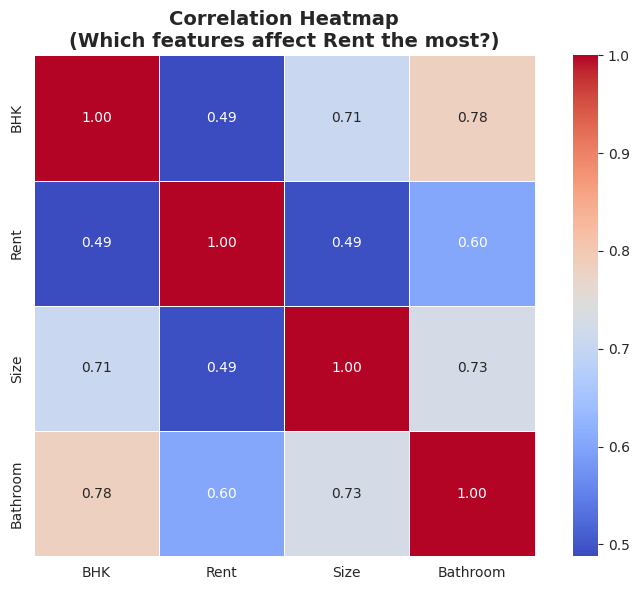

✅ Heatmap complete!

Reading the heatmap:
  → Values close to 1.0 in the 'Rent' row/column = strong impact on rent
  → BHK and Size should show the highest correlation with Rent


In [23]:
# ============================================================
# Correlation heatmap
# ============================================================

plt.figure(figsize=(8, 6))

numeric_df = df.select_dtypes(include='number')
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap\n(Which features affect Rent the most?)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Heatmap complete!")
print("\nReading the heatmap:")
print("  → Values close to 1.0 in the 'Rent' row/column = strong impact on rent")
print("  → BHK and Size should show the highest correlation with Rent")

In [24]:
# ============================================================
# Encode text columns & prepare data for ML
# ============================================================

le_dict = {}

text_columns = ['City', 'Furnishing Status', 'Tenant Preferred']

print("Converting text columns to numbers:")
for col in text_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f"  '{col}' encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nData after encoding (first 3 rows):")
print(df.head(3))

X = df.drop('Rent', axis=1)
y = df['Rent']

print(f"\nFeatures (X) — {X.shape[1]} columns: {X.columns.tolist()}")
print(f"Target (y): Rent")


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\n✅ Data split complete!")
print(f"   Training apartments : {X_train.shape[0]}")
print(f"   Testing apartments  : {X_test.shape[0]}")

Converting text columns to numbers:
  'City' encoded: {'Bangalore': np.int64(0), 'Chennai': np.int64(1), 'Delhi': np.int64(2), 'Hyderabad': np.int64(3), 'Kolkata': np.int64(4), 'Mumbai': np.int64(5)}
  'Furnishing Status' encoded: {'Furnished': np.int64(0), 'Semi-Furnished': np.int64(1), 'Unfurnished': np.int64(2)}
  'Tenant Preferred' encoded: {'Bachelors': np.int64(0), 'Bachelors/Family': np.int64(1), 'Family': np.int64(2)}

Data after encoding (first 3 rows):
    Posted On  BHK   Rent  Size  City  Furnishing Status  Tenant Preferred  \
0  2022-05-18    2  10000  1100     4                  2                 1   
1  2022-05-13    2  20000   800     4                  1                 1   
2  2022-05-16    2  17000  1000     4                  1                 1   

   Bathroom  
0         2  
1         1  
2         1  

Features (X) — 7 columns: ['Posted On', 'BHK', 'Size', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom']
Target (y): Rent

✅ Data split complete!
   Tra

In [25]:
# ============================================================
# Train Model 1 — Linear Regression
# ============================================================

print("Training Linear Regression model...")
lr_model = LinearRegression()

X_train_numeric = X_train.drop('Posted On', axis=1)
X_test_numeric = X_test.drop('Posted On', axis=1)

lr_model.fit(X_train_numeric, y_train)

lr_predictions = lr_model.predict(X_test_numeric)

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2  = r2_score(y_test, lr_predictions)

print("\n📊 LINEAR REGRESSION RESULTS:")
print(f"   Mean Absolute Error (MAE): ₹{lr_mae:,.0f}")
print(f"   R² Score               : {lr_r2:.3f}")
print(f"\n   ► MAE means: on average, predictions are off by ₹{lr_mae:,.0f}")
print(f"   ► R² of {lr_r2:.2f} means the model explains {lr_r2*100:.0f}% of rent variation")
print("   (R² of 1.0 = perfect, 0.0 = useless)")

Training Linear Regression model...

📊 LINEAR REGRESSION RESULTS:
   Mean Absolute Error (MAE): ₹19,595
   R² Score               : 0.541

   ► MAE means: on average, predictions are off by ₹19,595
   ► R² of 0.54 means the model explains 54% of rent variation
   (R² of 1.0 = perfect, 0.0 = useless)


In [26]:
# ============================================================
# Train Model 2 — Random Forest
# ============================================================

print("Training Random Forest model (may take 10-20 seconds)...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

X_train_numeric = X_train.drop('Posted On', axis=1)
X_test_numeric = X_test.drop('Posted On', axis=1)

rf_model.fit(X_train_numeric, y_train)
print("✅ Training complete!\n")

rf_predictions = rf_model.predict(X_test_numeric)

# Measure accuracy
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2  = r2_score(y_test, rf_predictions)

print("📊 RANDOM FOREST RESULTS:")
print(f"   Mean Absolute Error (MAE): ₹{rf_mae:,.0f}")
print(f"   R² Score               : {rf_r2:.3f}")

# ---- Compare both models side by side ----
print("\n" + "=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"  Linear Regression  — MAE: ₹{lr_mae:,.0f}  |  R²: {lr_r2:.3f}")
print(f"  Random Forest      — MAE: ₹{rf_mae:,.0f}  |  R²: {rf_r2:.3f}")
print("\n🏆 Random Forest wins! Lower MAE = better predictions.")
print("   We'll use Random Forest for all predictions.")

Training Random Forest model (may take 10-20 seconds)...
✅ Training complete!

📊 RANDOM FOREST RESULTS:
   Mean Absolute Error (MAE): ₹11,008
   R² Score               : 0.754

MODEL COMPARISON
  Linear Regression  — MAE: ₹19,595  |  R²: 0.541
  Random Forest      — MAE: ₹11,008  |  R²: 0.754

🏆 Random Forest wins! Lower MAE = better predictions.
   We'll use Random Forest for all predictions.


Feature Importance (higher = more impact on rent):
          Feature  Importance
             Size    0.339490
         Bathroom    0.294352
             City    0.276045
Furnishing Status    0.037298
 Tenant Preferred    0.028965
              BHK    0.023851


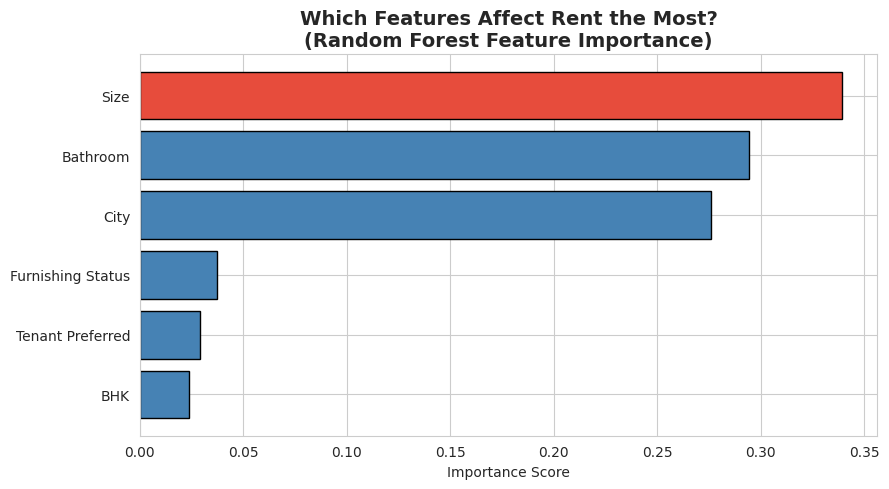


✅ The top feature is highlighted in red.


In [27]:
# ============================================================
# Which features affect rent the most?
# ============================================================

features_for_importance = X_train_numeric.columns

feature_importance_df = pd.DataFrame({
    'Feature': features_for_importance,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

print("Feature Importance (higher = more impact on rent):")
print(feature_importance_df.sort_values('Importance', ascending=False).to_string(index=False))

# Plot it
plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if i == len(feature_importance_df)-1 else 'steelblue'
          for i in range(len(feature_importance_df))]
plt.barh(feature_importance_df['Feature'],
         feature_importance_df['Importance'],
         color=colors, edgecolor='black')
plt.title('Which Features Affect Rent the Most?\n(Random Forest Feature Importance)',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
print("\n✅ The top feature is highlighted in red.")

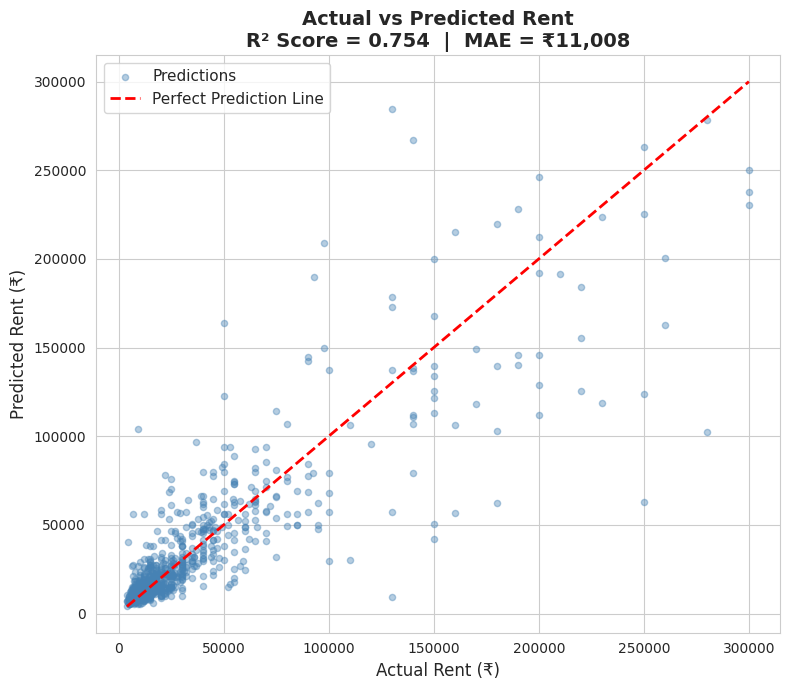


✅ Chart complete!
   Dots clustered near the red line = good model!
   Our model's R² is 0.754 — it explains 75% of rent variation.


In [28]:
# ============================================================
# CELL 12: Actual vs Predicted scatter plot
# ============================================================

plt.figure(figsize=(8, 7))

plt.scatter(y_test, rf_predictions, alpha=0.4, color='steelblue', s=20, label='Predictions')

min_val = min(y_test.min(), rf_predictions.min())
max_val = max(y_test.max(), rf_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', lw=2, label='Perfect Prediction Line')

plt.title(f'Actual vs Predicted Rent\nR² Score = {rf_r2:.3f}  |  MAE = ₹{rf_mae:,.0f}',
          fontsize=14, fontweight='bold')
plt.xlabel('Actual Rent (₹)', fontsize=12)
plt.ylabel('Predicted Rent (₹)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n✅ Chart complete!")
print(f"   Dots clustered near the red line = good model!")
print(f"   Our model's R² is {rf_r2:.3f} — it explains {rf_r2*100:.0f}% of rent variation.")

In [29]:
# ============================================================
# Save the trained model and download it
# ============================================================

# Save the Random Forest model
joblib.dump(rf_model, 'rent_model.pkl')
print("✅ Model saved as 'rent_model.pkl'")

# Save the text encoders
joblib.dump(le_dict, 'label_encoders.pkl')
print("✅ Encoders saved as 'label_encoders.pkl'")

# ---- Download files to your computer ----
print("\nDownloading files to your computer...")
from google.colab import files
files.download('rent_model.pkl')
files.download('label_encoders.pkl')
files.download('cleaned_rent_data.csv')
print("\n✅ Files downloaded! Check your Downloads folder.")
print("   (Your browser may ask permission to download multiple files — allow it)")

✅ Model saved as 'rent_model.pkl'
✅ Encoders saved as 'label_encoders.pkl'



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Files downloaded! Check your Downloads folder.
   (Your browser may ask permission to download multiple files — allow it)


In [30]:
# ============================================================
# Build a prediction function
# ============================================================

def predict_rent(bhk, size, city, furnishing, tenant, bathrooms):
    """
    Predict monthly rent for any apartment in India.

    Inputs:
      bhk        → Number of bedrooms: 1, 2, 3, 4, or 5
      size       → Size in square feet: e.g. 600, 1000, 1500
      city       → One of: 'Mumbai', 'Delhi', 'Bangalore',
                           'Hyderabad', 'Chennai', 'Kolkata',
                           'Pune', 'Ahmedabad'
      furnishing → 'Furnished', 'Semi-Furnished', or 'Unfurnished'
      tenant     → 'Bachelors', 'Family', or 'Bachelors/Family'
      bathrooms  → Number of bathrooms: 1, 2, or 3
    """

    valid_cities = list(le_dict['City'].classes_)
    if city not in valid_cities:
        print(f"❌ Invalid city '{city}'")
        print(f"   Valid options: {valid_cities}")
        return None

    valid_furn = list(le_dict['Furnishing Status'].classes_)
    if furnishing not in valid_furn:
        print(f"❌ Invalid furnishing '{furnishing}'")
        print(f"   Valid options: {valid_furn}")
        return None

    valid_tenant = list(le_dict['Tenant Preferred'].classes_)
    if tenant not in valid_tenant:
        print(f"❌ Invalid tenant '{tenant}'")
        print(f"   Valid options: {valid_tenant}")
        return None

    city_num     = le_dict['City'].transform([city])[0]
    furn_num     = le_dict['Furnishing Status'].transform([furnishing])[0]
    tenant_num   = le_dict['Tenant Preferred'].transform([tenant])[0]

    input_row = pd.DataFrame(
        [[bhk, size, city_num, furn_num, tenant_num, bathrooms]],
        columns=['BHK', 'Size', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom']
    )

    predicted_rent = rf_model.predict(input_row)[0]
    return int(predicted_rent)

print("✅ Prediction function ready!")
print("   Now run Cell 15 to see predictions.")

✅ Prediction function ready!
   Now run Cell 15 to see predictions.


In [31]:
# ============================================================
# Test predictions & try your own apartment
# ============================================================

print("=" * 60)
print("      🏠 RENT PRICE PREDICTIONS")
print("=" * 60)


test_cases = [
    {
        "bhk": 2,
        "size": 1000,
        "city": "Bangalore",
        "furnishing": "Semi-Furnished",
        "tenant": "Family",
        "bathrooms": 2
    },

    {
        "bhk": 3,
        "size": 1500,
        "city": "Mumbai",
        "furnishing": "Furnished",
        "tenant": "Bachelors/Family",
        "bathrooms": 2
    },

    {
        "bhk": 1,
        "size": 600,
        "city": "Chennai",      # Changed from Pune
        "furnishing": "Unfurnished",
        "tenant": "Bachelors",
        "bathrooms": 1
    },

    {
        "bhk": 4,
        "size": 2200,
        "city": "Delhi",
        "furnishing": "Furnished",
        "tenant": "Family",
        "bathrooms": 3
    },

    {
        "bhk": 2,
        "size": 900,
        "city": "Hyderabad",
        "furnishing": "Semi-Furnished",
        "tenant": "Bachelors/Family",
        "bathrooms": 1
    }
]

# ------------------------------------------------------------
# RUN ALL TEST CASES
# ------------------------------------------------------------

for i, case in enumerate(test_cases, 1):

    rent = predict_rent(**case)

    print(f"\nTest {i}")
    print("-" * 40)

    print(
        f"{case['bhk']} BHK | "
        f"{case['size']} sqft | "
        f"{case['city']} | "
        f"{case['furnishing']}"
    )

    if rent is not None:
        print(f"Predicted Rent: ₹{rent:,}/month")
    else:
        print("Prediction could not be generated.")

# ============================================================
# USER INPUT SECTION
# ============================================================

print("\n" + "=" * 60)
print("      🎯 TRY YOUR OWN APARTMENT")
print("=" * 60)

print("Supported Cities:")
print(", ".join(le_dict['City'].classes_))

print("\nFurnishing Options:")
print("Furnished")
print("Semi-Furnished")
print("Unfurnished")

print("\nTenant Options:")
print("Bachelors")
print("Family")
print("Bachelors/Family")

print("\nEnter your apartment details below:\n")

# ------------------------------------------------------------
# TAKE USER INPUT
# ------------------------------------------------------------

my_bhk = int(input("Enter BHK (1/2/3/4/5): "))

my_size = int(
    input("Enter Apartment Size in sqft (e.g. 1200): ")
)

my_city = input(
    "Enter City exactly as shown above: "
)

my_furnish = input(
    "Enter Furnishing Status: "
)

my_tenant = input(
    "Enter Tenant Preference: "
)

my_bathrooms = int(
    input("Enter Number of Bathrooms: ")
)

# ------------------------------------------------------------
# PREDICT RENT
# ------------------------------------------------------------

my_rent = predict_rent(
    bhk=my_bhk,
    size=my_size,
    city=my_city,
    furnishing=my_furnish,
    tenant=my_tenant,
    bathrooms=my_bathrooms
)

# ------------------------------------------------------------
# DISPLAY RESULT
# ------------------------------------------------------------

if my_rent is not None:

    print("\n" + "=" * 40)
    print("✅ RENT ESTIMATION RESULT")
    print("=" * 40)

    print(f"Estimated Monthly Rent: ₹{my_rent:,}")

    print("=" * 40)

else:
    print("\n❌ Prediction failed.")
    print("Please check your inputs and try again.")

      🏠 RENT PRICE PREDICTIONS

Test 1
----------------------------------------
2 BHK | 1000 sqft | Bangalore | Semi-Furnished
Predicted Rent: ₹16,767/month

Test 2
----------------------------------------
3 BHK | 1500 sqft | Mumbai | Furnished
Predicted Rent: ₹167,900/month

Test 3
----------------------------------------
1 BHK | 600 sqft | Chennai | Unfurnished
Predicted Rent: ₹7,235/month

Test 4
----------------------------------------
4 BHK | 2200 sqft | Delhi | Furnished
Predicted Rent: ₹71,727/month

Test 5
----------------------------------------
2 BHK | 900 sqft | Hyderabad | Semi-Furnished
Predicted Rent: ₹12,345/month

      🎯 TRY YOUR OWN APARTMENT
Supported Cities:
Bangalore, Chennai, Delhi, Hyderabad, Kolkata, Mumbai

Furnishing Options:
Furnished
Semi-Furnished
Unfurnished

Tenant Options:
Bachelors
Family
Bachelors/Family

Enter your apartment details below:

Enter BHK (1/2/3/4/5): 1
Enter Apartment Size in sqft (e.g. 1200): 1000
Enter City exactly as shown above: Mumba

In [32]:
print("\nMODEL SUMMARY")
print("="*50)
print(f"Dataset Size : {len(df):,} apartments")
print(f"Features Used: {len(X.columns)}")
print(f"MAE          : ₹{rf_mae:,.0f}")
print(f"R² Score     : {rf_r2:.3f}")
print(f"Accuracy     : {rf_r2*100:.1f}%")
print("="*50)


MODEL SUMMARY
Dataset Size : 4,636 apartments
Features Used: 7
MAE          : ₹11,008
R² Score     : 0.754
Accuracy     : 75.4%
